# Factor Bar Chart and Timeseries Figures

In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

In [2]:
# force the math text to look normal
mpl.rcParams['mathtext.default'] = 'regular'

def major_ticks(x, pos=None):
    """Set the major ticks according 
    to this custom style
    """
    x = mdates.num2date(x)
    if pos == 0:
        fmt = "%-d\n%b %Y\n%I %p"
    else:
        fmt = "%-d"
    return x.strftime(fmt)

# set the default seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
#load in the comp data
comp = pd.read_csv('C:/Users/alexa/Jupyter Notebook/MOD-00683/4_factor_resid.csv')
comp.rename(columns={'Unnamed: 0':'species'},inplace=True)
comp

,species,Factor 1,Factor 2,Factor 3,Factor 4,Residual
0,co,0.527110,0.114870,0.324523,0.014536,0.018961
1,no,0.573141,0.070009,0.324095,0.015045,0.017710
2,no2,0.122704,0.018366,0.863970,0.000065,-0.005104
3,o3,0.935411,0.070715,0.000000,0.000000,-0.006127
4,bin0,0.224225,0.786187,0.000000,0.000000,-0.010412
5,bin1,0.000000,0.784441,0.000000,0.336230,-0.120671
6,bin2,0.000000,0.464087,0.000000,0.617696,-0.081783
7,bin3,0.031467,0.190121,0.005140,0.784054,-0.010781
8,bin4,0.276308,0.030230,0.000000,0.700213,-0.006751
9,bin5,0.387440,0.000000,0.008773,0.607755,-0.003968


In [4]:
comp2 = pd.melt(comp,id_vars='species', value_vars=['Factor 1','Factor 2','Factor 3','Residual'])
comp2

,species,variable,value
0,co,Factor 1,0.527110
1,no,Factor 1,0.573141
2,no2,Factor 1,0.122704
3,o3,Factor 1,0.935411
4,bin0,Factor 1,0.224225
5,bin1,Factor 1,0.000000
6,bin2,Factor 1,0.000000
7,bin3,Factor 1,0.031467
8,bin4,Factor 1,0.276308
9,bin5,Factor 1,0.387440


In [7]:
#load in the timeseries data
ts = pd.read_csv('C:/Users/alexa/Jupyter Notebook/MOD-00683/MOD-00683_timeseries_hourly_scaled.csv').reset_index()
results = pd.read_csv('C:/Users/alexa/Jupyter Notebook/MOD-00683/4_factor_results.csv')

ts = pd.concat([ts,results['Factor 1'],results['Factor 2'], results['Factor 3']], axis = 1)
cols_reordered = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','co','o3','no','no2','Factor 1','Factor 2','Factor 3']
ts = ts[cols_reordered]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3
0,2025-04-15 12:00:00,0.103624,0.025592,0.018170,0.018617,0.037037,0.041420,0.473146,0.753736,0.041589,0.581735,0.076130,0.011327,0.072640
1,2025-04-15 13:00:00,0.063488,0.016635,0.012786,0.013298,0.029630,0.035503,0.431304,0.728937,0.049737,0.492153,0.074788,0.002060,0.059946
2,2025-04-15 14:00:00,0.033933,0.011196,0.010094,0.013298,0.029630,0.035503,0.355810,0.716266,0.050586,0.171970,0.074691,0.000000,0.012826
3,2025-04-15 15:00:00,0.021892,0.009277,0.008748,0.010638,0.029630,0.035503,0.328399,0.718432,0.048379,0.182868,0.073792,0.000000,0.013462
4,2025-04-15 16:00:00,0.018122,0.007678,0.008075,0.010638,0.025926,0.029586,0.319780,0.684644,0.034290,0.307977,0.069075,0.000000,0.031942


In [8]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local']) #convert timestamp column to pandas timestamp format
ts = ts.set_index('timestamp_local',append=False) #setindex as local time
ts

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3
timestamp_local,,,,,,,,,,,,,
2025-04-15 12:00:00,0.103624,0.025592,0.018170,0.018617,0.037037,0.041420,0.473146,0.753736,0.041589,0.581735,0.076130,0.011327,0.072640
2025-04-15 13:00:00,0.063488,0.016635,0.012786,0.013298,0.029630,0.035503,0.431304,0.728937,0.049737,0.492153,0.074788,0.002060,0.059946
2025-04-15 14:00:00,0.033933,0.011196,0.010094,0.013298,0.029630,0.035503,0.355810,0.716266,0.050586,0.171970,0.074691,0.000000,0.012826
2025-04-15 15:00:00,0.021892,0.009277,0.008748,0.010638,0.029630,0.035503,0.328399,0.718432,0.048379,0.182868,0.073792,0.000000,0.013462
2025-04-15 16:00:00,0.018122,0.007678,0.008075,0.010638,0.025926,0.029586,0.319780,0.684644,0.034290,0.307977,0.069075,0.000000,0.031942
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27 13:00:00,0.058502,0.023672,0.018170,0.015957,0.025926,0.029586,0.436934,0.338856,0.027669,0.606146,0.036852,0.012209,0.088146
2025-12-27 14:00:00,0.060448,0.021753,0.014132,0.013298,0.022222,0.023669,0.472978,0.338965,0.029367,0.598300,0.037874,0.014056,0.088127
2025-12-27 15:00:00,0.059110,0.021433,0.015478,0.013298,0.022222,0.023669,0.491520,0.326186,0.029706,0.615301,0.037061,0.014574,0.091505


In [10]:
#taking daily average of ts. round to floor of the day
ts = ts.reset_index()

ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  factor1 = ('Factor 1','mean'),
                                                  factor2 = ('Factor 2','mean'),
                                                  factor3 = ('Factor 3','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

C:\Users\alexa\AppData\Local\Temp\ipykernel_20084\1362620111.py:4: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),


,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,factor1,factor2,factor3
timestamp_local,,,,,,,,,,,,,
2025-04-15,0.030605,0.009510,0.007953,0.008946,0.019192,0.022055,0.357669,0.657865,0.041882,0.407942,0.066743,0.001217,0.048094
2025-04-16,0.010989,0.003368,0.002375,0.002660,0.003704,0.005917,0.337277,0.571902,0.037774,0.335017,0.059148,0.000000,0.039993
2025-04-17,0.031298,0.008304,0.006309,0.005984,0.010185,0.010602,0.354540,0.588563,0.036475,0.406504,0.060536,0.000453,0.050036
2025-04-18,0.085320,0.037615,0.035778,0.041999,0.074691,0.086045,0.430033,0.544866,0.160881,0.612649,0.055869,0.010747,0.082504
2025-04-19,0.145919,0.040507,0.037993,0.049535,0.094753,0.120316,0.375538,0.593134,0.046547,0.440306,0.058411,0.021335,0.053823


## Setting Up Barchart and 6-month Figures

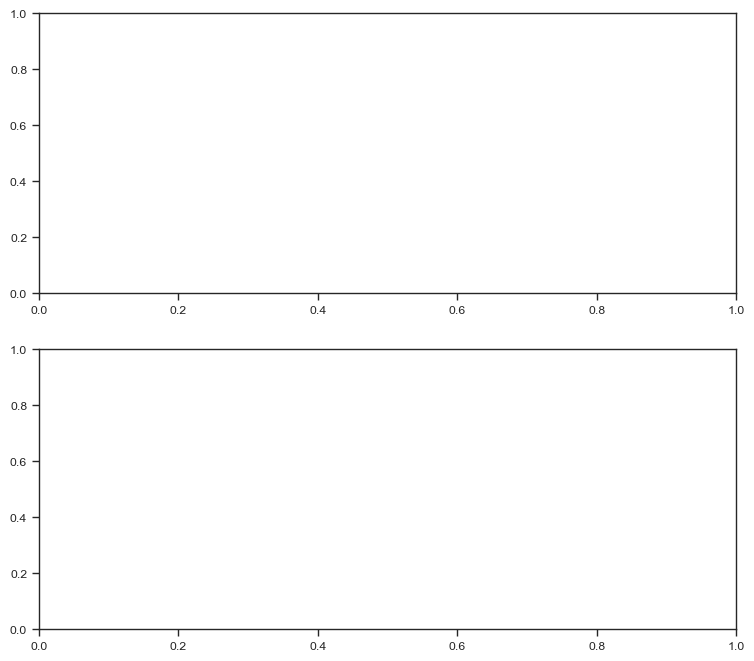

In [11]:
# set up the figure
fig = plt.figure(figsize=(9, 8))

ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

In [12]:
cols = ['bin0', 'bin1', 'bin2','bin3','bin4','bin5','co', 'o3','no', 'no2']

pal = sns.color_palette()

colors = [pal[3], pal[2], pal[4], pal[5]]
colors += sns.color_palette("Blues", 6)
colors.reverse()

In [13]:
ax1 = sns.barplot(x='variable',y='value',
        data=comp2,
        ax=ax1, hue='species',hue_order=cols,
        palette=colors, saturation=1, edgecolor='black', linewidth=0.25,
        errwidth=.75)

C:\Users\alexa\AppData\Local\Temp\ipykernel_20084\2976516543.py:1: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.75}` instead.

  ax1 = sns.barplot(x='variable',y='value',


In [14]:
ax1.set_ylim(-0.2, 1)
ax1.set_xlabel("")
ax1.set_ylabel("Percent of Species Signal\nDescribed by Factor", fontsize=14)
ax1.set(yticks=np.linspace(-0.2, 1, 13), yticklabels=["","","0","","","","","50","","","","","100"])
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.axhline(y=0, color='black', linestyle='-', lw =0.5)

In [15]:
handles, _ = ax1.get_legend_handles_labels()
labels = ["Bin 0", "Bin 1", "Bin 2", "Bin 3","Bin 4","Bin 5","CO","$O_3$","$NO$", "$NO_2$"]
ax1.legend(handles, labels)

In [16]:
ax2.plot(ts_day.index, ts_day["factor1"], label="Factor 1 ", lw=1, color=sns.xkcd_rgb['slate blue'])
ax2.plot(ts_day.index, ts_day["factor2"], label="Factor 2", lw=1, color=sns.xkcd_rgb['dull green'])
ax2.plot(ts_day.index, ts_day["factor3"], label="Factor 3", lw=1, color=sns.xkcd_rgb['dark lavender'])

ax2.set_ylabel("Factor Intensity (a.u.)", fontsize=14)

#last 6 months
ax2.set_xlim(ts_day.index[-180], ts_day.index[-1])
#ax2.set_xlim(ts_day.index[0], ts_day.index[-1])

ax2.legend(loc='upper right',fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=14)

In [17]:
ax1.set_title('(a)',fontsize=14)
ax2.set_title('(b)',fontsize=14)

Text(0.5, 1.0, '(b)')

In [18]:
plt.gcf().text(0.09, 0.9, "(a)", fontsize=12)
plt.gcf().text(0.5, 0.9, "(b)", fontsize=12)
plt.gcf().text(0.09,0.9,'MOD-00397',fontsize=12)

plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [19]:
# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/time_barchart_MOD-00068_4_factor.png')

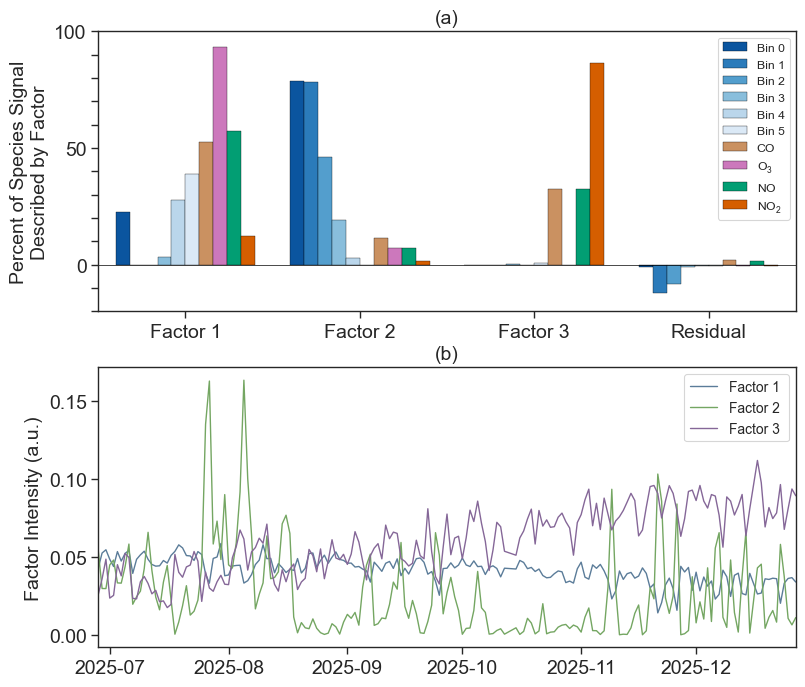

In [20]:
fig

## Setting Up Diurnal Figure

In [21]:
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3
0,2025-04-15 12:00:00,0.103624,0.025592,0.018170,0.018617,0.037037,0.041420,0.473146,0.753736,0.041589,0.581735,0.076130,0.011327,0.072640
1,2025-04-15 13:00:00,0.063488,0.016635,0.012786,0.013298,0.029630,0.035503,0.431304,0.728937,0.049737,0.492153,0.074788,0.002060,0.059946
2,2025-04-15 14:00:00,0.033933,0.011196,0.010094,0.013298,0.029630,0.035503,0.355810,0.716266,0.050586,0.171970,0.074691,0.000000,0.012826
3,2025-04-15 15:00:00,0.021892,0.009277,0.008748,0.010638,0.029630,0.035503,0.328399,0.718432,0.048379,0.182868,0.073792,0.000000,0.013462
4,2025-04-15 16:00:00,0.018122,0.007678,0.008075,0.010638,0.025926,0.029586,0.319780,0.684644,0.034290,0.307977,0.069075,0.000000,0.031942


In [22]:
#prepping data
ts = ts.set_index('timestamp_local')
ts['Hour'] = ts.index.hour
ts.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Hour
timestamp_local,,,,,,,,,,,,,,
2025-04-15 12:00:00,0.103624,0.025592,0.018170,0.018617,0.037037,0.041420,0.473146,0.753736,0.041589,0.581735,0.076130,0.011327,0.072640,12
2025-04-15 13:00:00,0.063488,0.016635,0.012786,0.013298,0.029630,0.035503,0.431304,0.728937,0.049737,0.492153,0.074788,0.002060,0.059946,13
2025-04-15 14:00:00,0.033933,0.011196,0.010094,0.013298,0.029630,0.035503,0.355810,0.716266,0.050586,0.171970,0.074691,0.000000,0.012826,14
2025-04-15 15:00:00,0.021892,0.009277,0.008748,0.010638,0.029630,0.035503,0.328399,0.718432,0.048379,0.182868,0.073792,0.000000,0.013462,15
2025-04-15 16:00:00,0.018122,0.007678,0.008075,0.010638,0.025926,0.029586,0.319780,0.684644,0.034290,0.307977,0.069075,0.000000,0.031942,16


In [24]:
#grouping by hour and calculate the mean
diurnal_data = ts.groupby('Hour')[['Factor 1','Factor 2','Factor 3']].mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,Factor 1,Factor 2,Factor 3
Hour,,,
00:00,0.040604,0.031671,0.062173
01:00,0.039750,0.031223,0.062905
02:00,0.038922,0.031069,0.061369
03:00,0.037884,0.032022,0.059585
04:00,0.036818,0.032490,0.060919
05:00,0.035143,0.034163,0.062562
06:00,0.033904,0.034282,0.066045
07:00,0.034171,0.033689,0.062268
08:00,0.035739,0.032753,0.054562


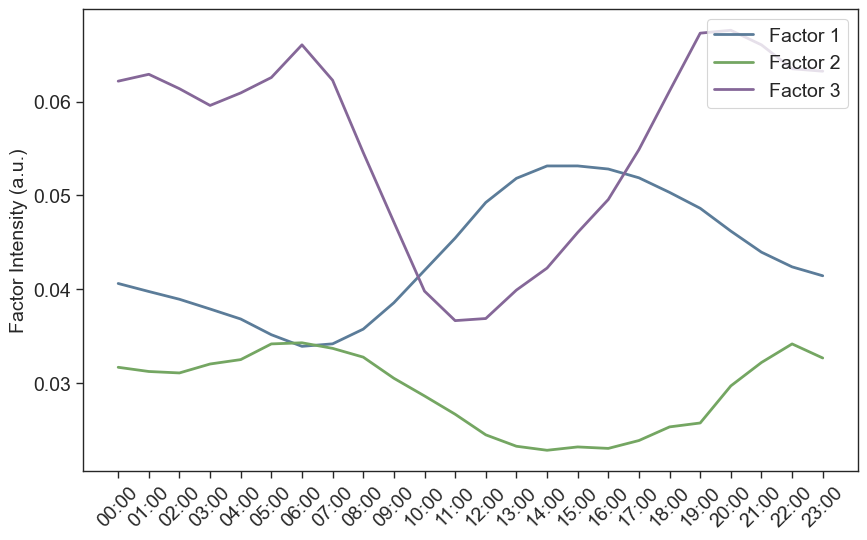

In [25]:
# set up the figure
plt.figure(figsize=(10, 6))

plt.plot(diurnal_data.index, diurnal_data['Factor 1'], label='Factor 1', lw = 2, color=sns.xkcd_rgb['slate blue'])
plt.plot(diurnal_data.index, diurnal_data['Factor 2'], label='Factor 2', lw = 2, color=sns.xkcd_rgb['dull green'])
plt.plot(diurnal_data.index, diurnal_data['Factor 3'], label='Factor 3', lw = 2, color=sns.xkcd_rgb['dark lavender'])

plt.ylabel('Factor Intensity (a.u.)', fontsize = 14)
plt.legend(loc='upper right',fontsize=14)
plt.xticks(range(0, 24))
plt.xticks(rotation=45)

plt.tick_params(labelsize=14)

# plt.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/diurnal_MOD-00068_4_factor.png')
plt.show()